# AlexNet

- CNN architecture 
    -  합성곱은 이미지를 필터를 사용해 변환하는 과정 
    - 그렇다면 풀링은? 풀리은 입력데이터의 자원을 줄이는 샘플링 방법, 주로 특정 영역의 특징을 집약하여 처리 
    - CNN아키텍처는 입력 데이터를 미분가능한 함수들을 사용해 출력 데이터로 변환하는 여러 층으로 구성, 이를 통해 이미지의 클래스 점수를 예측 
        - 이런 층들의 배열은 여러 변형이 가능하여, 다양한 CNN아키텍처가 개발됨. 

## AlexNet

- 방대한 이미지 데이터셋인 ImageNet을 사용하여 알고리즘을 평가하고 다양한 시각 인식 작업에 높은 정확도를 달성하기 위해 경쟁하는 대회 
- 다중 합성곱 층, 풀링층, 완전 연결 층으로 구성된 깊은 구조
- ImageNet은 1000개의 카테고리로 라벨이 지정된 약 1400만 개의 고해상도 이미지로 구성된 이미지 데이터 베이스 
- AlexNet의 입력 크기는 `227x227x3`(RGB)이미지  

## AlexNet의 주요 특징 

### 1. ReLU 활성화 함수 

- 이전 신경망에서는 주로 시그모이드와 tanh함수를 사용했기 때문에 `gradient 소실`문제가 있었음. 
- 이 함수들은 값이 너무 커지거나 작아지면 출력을 일정하게 만들어, 역전파 중 그래디언트가 거의 0이 되게 한다. 

$$
|f(x) = max(0, x)|
$$

## 2. 과적합 문제 해결 방법

- 데이터 증강 ( Data Augmentation )
    - 원래 이미지를 무작위로 변경하여 새로운 이미지를 만드는 방법
    - 자르기, 뒤집기, 회전, 노이즈 추가, 색상 변경 등 
    - 훈련 데이터 세트의 크기와 다양성이 크게 늘어나게 된다. 
    - 모델의 일반화 능력이 향상, 학습 속도와 정확도가 높아짐. 
    - 과적합 문제를 줄일 수 있다. 
- 드롭 아웃(dropout)
    - 각 계층의 일부 뉴런을 무작위로 비활성화 
    - 신경망이 각 반복에서 다른 뉴런 조합에 의존하도록 강제, 훈련 데이터의 특정 기능에 대한 의존을 억제
    - 과적합을 피하고 모델의 일반화 능력을 높이는 데 도움 
    - AlexNet의 fully connected layer 두개를 사용하는데 매우많은 수의 뉴런(각각 4096개)을 사용하기 때문에 과적합에 취약 
    - AlexNet은 50%의 드롭아웃 비율을 사용하는데, 이는 각 계층의 뉴런의 절반이 훈련중에 무작위로 드롭아웃 된다는 것을 의미, 이러한 높은 비율은 큰 계층에서 과적합을 방지하는 것의 중요성을 강조 

## 3. GPU 도입

- AlexNet 이전에는 CPU를 주로 사용하여 모델을 훈련, GPU처리에 직접 엑세스 할 수 없었기 때문
- Nvidia가 CUDA API를 출시 하면서 GPU를 사용하여 병렬 처리 엑세스 가능해짐
- AlexNet은 GPU를 사용하여 대규모 데이터 셋을 효율적으로 처리하고 훈련 속도를 크게 향상 

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F

## AlexNet

- 5개의 합성곱층, 3개의 완전 연결층 

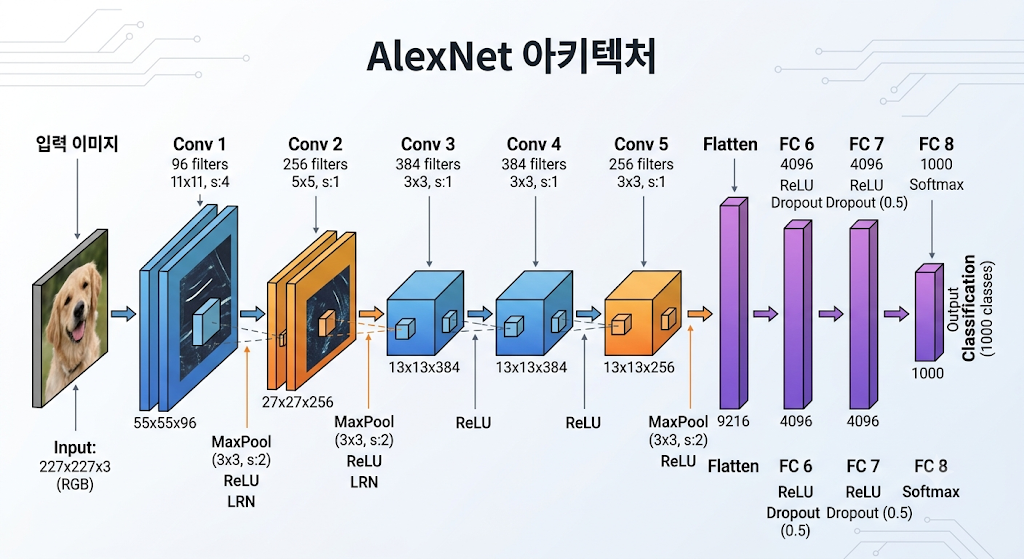

In [2]:
# 0️⃣ 임의의 입력 데이터 생성 (1채널, 227x227 이미지)
x = torch.randn(1, 3, 227, 227)
print(f'Input shape: {x.shape}')

Input shape: torch.Size([1, 3, 227, 227])


In [3]:
# 1️⃣ 첫 번째 합성곱 층 (Conv1)
conv1 = nn.Conv2d(3, 96, kernel_size=11, stride=4, padding=1)
x = F.relu(conv1(x))
print(f'After Conv1: {x.shape}')

# 2️⃣ 첫 번째 맥스 풀링 층 (MaxPool1)
pool1 = nn.MaxPool2d(kernel_size=3, stride=2)
x = pool1(x)
print(f'After Pool1: {x.shape}')

After Conv1: torch.Size([1, 96, 55, 55])
After Pool1: torch.Size([1, 96, 27, 27])


In [4]:
# 3️⃣ 두 번째 합성곱 층 (Conv2) & 4️⃣ 두 번째 맥스 풀링 층 (MaxPool2)
conv2 = nn.Conv2d(96, 256, kernel_size=5, stride=1, padding=2)
x = F.relu(conv2(x)) # 활성화 함수 적용
x = pool1(x)         # 맥스 풀링 적용
print(f'After Pool2: {x.shape}')

After Pool2: torch.Size([1, 256, 13, 13])


In [5]:
# 5️⃣ 6️⃣ 7️⃣ 세 번째, 네 번째, 다섯 번째 합성곱 층 (Conv3)
conv3 = nn.Conv2d(256, 384, kernel_size=3, stride=1, padding=1)
x = F.relu(conv3(x))

conv4 = nn.Conv2d(384,384, kernel_size=3, stride=1, padding=1)
x = F.relu(conv4(x))

conv5 = nn.Conv2d(384, 256, kernel_size=3, stride=1, padding=1)
x = F.relu(conv5(x))

# 8️⃣ 세 번째 맥스 풀링 층 (MaxPool3)
pool3 = nn.MaxPool2d(kernel_size=3, stride=2)
x = pool3(x)

print(f'After Pool3: {x.shape}')

After Pool3: torch.Size([1, 256, 6, 6])


In [6]:
# Flatten
x = x.view(x.size(0), -1)

# 9️⃣ 첫 번째 드롭아웃 층 (Dropout1)
dropout1 = nn.Dropout(p=0.5)
x = dropout1(x)

# 🔟 첫 번째 완전 연결 층 (FC1)
fc1 = nn.Linear(256 * 6 * 6, 4096)
x = F.relu(fc1(x))
print(f'After FC1: {x.shape}')

# 1️⃣1️⃣ 두 번째 드롭아웃 층 (Dropout2)
dropout2 = nn.Dropout(p=0.5)
x = dropout2(x)

# 1️⃣2️⃣ 두 번째 완전 연결 층 (FC2)
fc2 = nn.Linear(4096, 4096)
x = F.relu(fc2(x))
print(f'After FC2: {x.shape}')

# 1️⃣3️⃣ 출력 층 (Output)
fc3 = nn.Linear(4096, 1000)
x = fc3(x)
print(f'Output shape: {x.shape}')

After FC1: torch.Size([1, 4096])
After FC2: torch.Size([1, 4096])
Output shape: torch.Size([1, 1000])


In [7]:
class AlexNet(nn.Module):
    def __init__(self):
        super(AlexNet, self).__init__()

        # 특징 추출 (feature extraction) 부분을 위한 레이어 정의
        self.conv1 = nn.Conv2d(3, 96, kernel_size=11, stride=4, padding=2)
        self.conv2 = nn.Conv2d(96, 256, kernel_size=5, stride=1, padding=2)
        self.conv3 = nn.Conv2d(256, 384, kernel_size=3, stride=1, padding=1)
        self.conv4 = nn.Conv2d(384, 384, kernel_size=3, stride=1, padding=1)
        self.conv5 = nn.Conv2d(384, 256, kernel_size=3, stride=1, padding=1)

        self.pool = nn.MaxPool2d(kernel_size=3, stride=2)

        # 분류기(Classifier) 부분을 위한 레이어 정의
        self.fc1 = nn.Linear(256 * 6 * 6, 4096)
        self.fc2 = nn.Linear(4096, 4096)
        self.fc3 = nn.Linear(4096, 1000)

        self.dropout = nn.Dropout()

    def forward(self, x):
        # 특징 추출 (feature extraction) 부분
        x = F.relu(self.conv1(x)) # conv + relu
        x = self.pool(x) # MaxPooling
        x = F.relu(self.conv2(x)) # conv + relu
        x = self.pool(x) # MaxPooling
        x = F.relu(self.conv3(x)) # conv + relu
        x = F.relu(self.conv4(x)) # conv + relu
        x = F.relu(self.conv5(x)) # conv + relu
        x = self.pool(x) # MaxPooling

        # 완전 연결 계층을 위한 텐서 평탄화
        x = x.view(x.size(0), -1)

        # 분류기(Classifier) 부분
        x = self.dropout(x) # Dropout
        x = F.relu(self.fc1(x)) # fc + relu
        x = self.dropout(x) # Dropout
        x = F.relu(self.fc2(x)) # fc + relu
        x = self.fc3(x) # fc

        return x

In [8]:
from torchsummary import summary

model = AlexNet()
summary(model, (3, 227, 227))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 96, 56, 56]          34,944
         MaxPool2d-2           [-1, 96, 27, 27]               0
            Conv2d-3          [-1, 256, 27, 27]         614,656
         MaxPool2d-4          [-1, 256, 13, 13]               0
            Conv2d-5          [-1, 384, 13, 13]         885,120
            Conv2d-6          [-1, 384, 13, 13]       1,327,488
            Conv2d-7          [-1, 256, 13, 13]         884,992
         MaxPool2d-8            [-1, 256, 6, 6]               0
           Dropout-9                 [-1, 9216]               0
           Linear-10                 [-1, 4096]      37,752,832
          Dropout-11                 [-1, 4096]               0
           Linear-12                 [-1, 4096]      16,781,312
           Linear-13                 [-1, 1000]       4,097,000
Total params: 62,378,344
Trainable para

In [9]:
from torchvision import models

AlexNet_model = models.alexnet(pretrained=True)
print(AlexNet_model)

/Users/donghun2/workspace/machine_learning/dacon/.venv/lib/python3.12/site-packages/torchvision/models/_utils.py:207: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/donghun2/workspace/machine_learning/dacon/.venv/lib/python3.12/site-packages/torchvision/models/_utils.py:222: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /Users/donghun2/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:04<00:00, 50.3MB/s] 


AlexNet(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (avgpool): AdaptiveAvgPool2d(output_size=(6, 6))
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=9216, out_features=4096, bias=True)
 

In [10]:
# 입력 데이터 생성
x = torch.randn(1, 3, 227, 227)

# 순전파
logits = AlexNet_model(x)
print(logits.shape)  # (1, 1000)

# 손실 함수 정의 및 사용
criterion = nn.CrossEntropyLoss()
target = torch.tensor([1])  # 예시 정답 레이블
loss = criterion(logits, target)
print(loss)

torch.Size([1, 1000])
tensor(10.9723, grad_fn=<NllLossBackward0>)
